In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
import torch
import pandas as pd
from scipy.linalg import lu_factor, lu_solve
from sklearn.model_selection import train_test_split

# Plots: 

In [11]:
def plot_loss(loss_fct, w_1_range, w_2_range, alone='no'):
    w1 = np.linspace(w_1_range[0], w_1_range[1], 1000)
    w2 = np.linspace(w_2_range[0], w_2_range[1], 1000)
    W1, W2 = np.meshgrid(w1, w2)
    Loss = loss_fct([W1, W2])

    if alone == 'yes':
        plt.figure(figsize=(6, 5))

    plt.imshow(
        Loss,

        extent=[w1.min(), w1.max(), w2.min(), w2.max()],
        origin='lower',
        aspect='auto',
        cmap='RdBu', alpha=0.5, vmin=0, vmax=2
    )
    plt.colorbar(label='L(w1, w2)')
    plt.xlabel('w1')
    plt.ylabel('w2')
    plt.title('Heatmap af weightspace (loss landscape)')

def plot_brownian(BM): 
    plt.plot(BM[:, 0], BM[:, 1], c='black', linewidth=1, label='path')
    plt.scatter(BM[:, 0], BM[:, 1], s=5, c='red')
    plt.scatter(BM[0,0], BM[0,1], c='red', s=50, label="start")
    plt.scatter(BM[-1,0], BM[-1,1], c='white', edgecolor='black', s=50, label="end")
    plt.legend()

def plot_optimization_steps(mu_history):
    # path line
    #plt.plot(mu_history[:, 0], mu_history[:, 1],
     #        c='lightblue', linewidth=1, alpha=0.8)
    # intermediate points
    plt.scatter(mu_history[:, 0], mu_history[:, 1],
                s=15, c='lightblue', alpha=0.9)
    # start
    plt.scatter(mu_history[0, 0], mu_history[0, 1],
                s=100, c='cornflowerblue', edgecolor='black', label="start")
    # final μ
    plt.scatter(mu_history[-2, 0], mu_history[-2, 1],
                s=120, c='royalblue', edgecolor='black', label="final μ")
    plt.legend()

def plot_loss_opt(steps,loss):
    plt.plot(steps,loss)
    plt.xlabel('nr of step')
    plt.ylabel('loss')
    plt.title('loss over optimisation')


def plot_optimization_overview(loss_fct, w_1_range, w_2_range, mu_history, steps, loss):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # ---- Left: Loss landscape + optimization path ----
    plt.sca(axes[0])  # set current axis
    plot_loss(loss_fct, w_1_range, w_2_range)
    plot_optimization_steps(mu_history)
    axes[0].set_title("Loss landscape with optimization of E[L] (with drift)")

    # ---- Right: Loss vs steps ----
    plt.sca(axes[1])
    plot_loss_opt(steps, loss)
    axes[1].set_title("Loss over optimization")

    plt.tight_layout()
    plt.show()

def Banan(theta):
    return np.exp(-(theta[0]*theta[1]-1)**2)



In [ ]:
# vi laver her noice injection for at sikre, at metrikken bliver positivt definit


def L(theta):
    epsi = 1e-6
    return (theta[0]*theta[1]-1)**2 + epsi

def grad_L(theta):
    loss = L(theta)
    (g,) = torch.autograd.grad(loss, theta, create_graph=True)
    return g


def L_batch(theta):
    # theta: (N, 2)
    epsi = 1e-6
    return (theta[:, 0] * theta[:, 1] - 1.0) ** 2 + epsi

def Metric(theta):
    g = grad_L(theta)    
    return torch.eye(2) + torch.outer(g, g)



def sqrt_M_inv(M, eps=1e-6):
    evals, evecs = torch.linalg.eigh(M)
    
    safe_evals = torch.clamp(evals, min=eps)
    return (evecs * (1.0 / torch.sqrt(safe_evals))) @ evecs.T


def compute_q(theta):
    M = Metric(theta)
    M_inv = torch.linalg.inv(M)
    M_det = torch.det(M)
    q = torch.sqrt(M_det) * M_inv
    return q, M_det

def compute_drift(theta):
    q, M_det = compute_q(theta)
    dq = torch.func.jacrev(lambda th: compute_q(th)[0])(theta) 
    sum_term = torch.einsum("lkl->k", dq)
    drift = (sum_term / (torch.sqrt(M_det)))
    return drift


def compute_BM(start_point, step_size, walk_length, random_state=None):
    if random_state is not None:
        torch.manual_seed(random_state)
    
    theta = torch.tensor(start_point, dtype=torch.float32, requires_grad=True)
    path = [theta.clone()]
    losses = []

    dt = torch.tensor(step_size)
    sqrt_dt = torch.sqrt(dt)

    for _ in range(walk_length):
        M = Metric(theta)
        Minv_sqrt = sqrt_M_inv(M)
        eps = torch.randn(2)

        drift_term = compute_drift(theta)
        theta = theta + 0.5 * dt * drift_term + sqrt_dt * (Minv_sqrt @ eps)
        path.append(theta.detach().clone())

        losses.append(L(theta))
    
    return torch.stack(path)


In [ ]:
def sample_q_endpoints(mu, n_samples, walk_len, step_size, detach_from_mu=False):
    samples = []
    dt = torch.tensor(step_size, dtype=mu.dtype, device=mu.device)
    sqrt_dt = torch.sqrt(dt)
    for _ in range(n_samples):
        if detach_from_mu:
            
            theta = mu.detach().clone().requires_grad_(True)
        else:
            
            theta = mu
        for _ in range(walk_len):
            M = Metric(theta)
            Minv_sqrt = sqrt_M_inv(M, eps=1e-6)
            eps = torch.randn(2, dtype=mu.dtype, device=mu.device)
            drift_term = compute_drift(theta)
            theta = theta + 0.5 * dt * drift_term + sqrt_dt * (Minv_sqrt @ eps)
  
        samples.append(theta.detach() if detach_from_mu else theta)
    return torch.stack(samples, dim=0)


In [ ]:
def VI_Brownian(mu_start, learning_rate, num_updates, BM_step_size, BM_walk_len, n_sampels, eps=1e-6, seed=None ):
    if seed is not None:
        torch.manual_seed(seed)

    mu = torch.nn.Parameter(torch.tensor([mu_start[0]+ eps, mu_start[1]+eps], dtype=torch.float64))
    opt = torch.optim.SGD([mu], lr=learning_rate)

    mu_history = [mu.detach().cpu().numpy().copy()]
    loss_history = []

    for k in range(num_updates):
        end_points = sample_q_endpoints(mu, n_sampels, BM_walk_len, BM_step_size, detach_from_mu=False )

        loss_est = L_batch(end_points).mean()

        opt.zero_grad()
        loss_est.backward()
        opt.step()

        loss_history.append(loss_est.detach().cpu().item())
        mu_history.append(mu.detach().cpu().numpy().copy())

        if torch.isnan(loss_est) or torch.isinf(loss_est):
            print(f"Stopping early at iter {k+1}: loss is NaN/Inf")
            break

        if (k + 1) % 50 == 0:
            print(f"iter {k+1:4d} | loss_est={loss_est.item():.6f} | mu={mu.detach().cpu().numpy()}")

    return np.array(mu_history), np.array(loss_history)

In [6]:
mu_start = [2.0, 2.0]
learning_rate = 0.01
num_updates = 300
BM_step_size = 0.01
BM_walk_len = 50
sampels =100
mu_path, loss = VI_Brownian(mu_start, learning_rate, num_updates, BM_step_size, BM_walk_len, sampels)


iter   50 | loss_est=2.166556 | mu=[1.56149791 1.56131911]
iter  100 | loss_est=0.685500 | mu=[1.32073998 1.32113609]
iter  150 | loss_est=0.720545 | mu=[1.35993299 1.32232083]
iter  200 | loss_est=0.456839 | mu=[1.31376058 1.24644689]
iter  250 | loss_est=0.528458 | mu=[1.27974109 1.19207611]
iter  300 | loss_est=0.451092 | mu=[1.25510029 1.15152523]


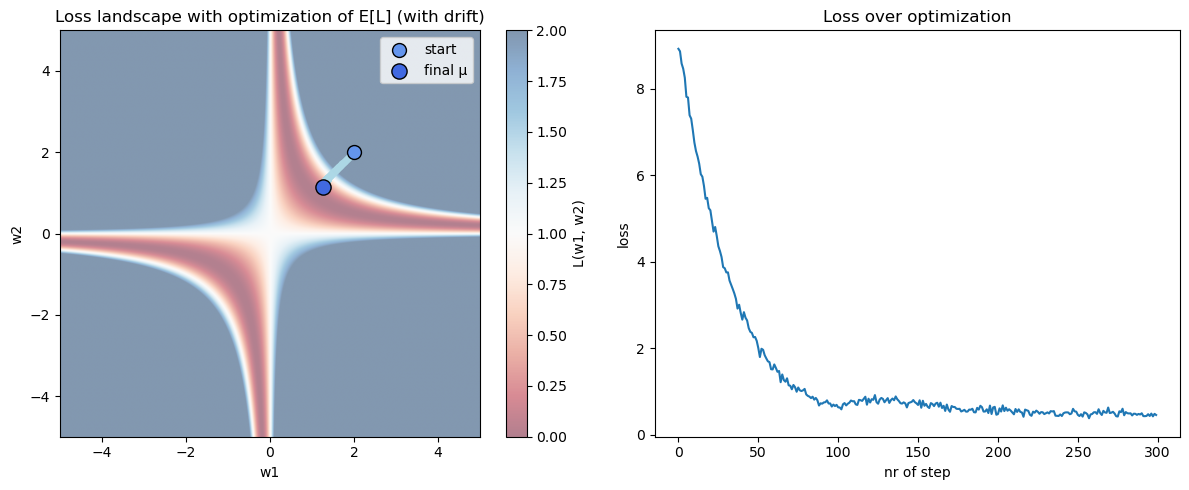

In [14]:
steps = range(len(loss))
plot_optimization_overview(L, [-5,5],[-5,5], mu_path, steps, loss)